In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dates = pd.date_range(start="2024-01-01", end="2025-12-31", freq="D")

np.random.seed(42)

sales = (
    5000
    + np.arange(len(dates)) * 5
    + 1000 * np.sin(np.arange(len(dates)) * 2 * np.pi / 365)
    + np.random.normal(0, 500, len(dates))
)

products = np.random.choice(
    ["Laptop", "Mobile", "Tablet", "Headphones"],
    len(dates)
)

categories = np.random.choice(
    ["Electronics", "Accessories"],
    len(dates)
)

df = pd.DataFrame({
    "Date": dates,
    "Sales": sales,
    "Product": products,
    "Category": categories
})

df.head()

,Date,Sales,Product,Category
0,2024-01-01,5248.357077,Mobile,Accessories
1,2024-01-02,4953.081206,Mobile,Accessories
2,2024-01-03,5368.265881,Laptop,Accessories
3,2024-01-04,5828.134595,Laptop,Accessories
4,2024-01-05,4971.725739,Laptop,Accessories


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      731 non-null    datetime64[us]
 1   Sales     731 non-null    float64       
 2   Product   731 non-null    str           
 3   Category  731 non-null    str           
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 23.0 KB


In [4]:
df.isnull().sum()

Date        0
Sales       0
Product     0
Category    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Sales"].describe()

count     731.000000
mean     6818.126627
std      1112.407786
min      3709.752638
25%      5921.968779
50%      6756.401192
75%      7729.355750
max      9860.164335
Name: Sales, dtype: float64

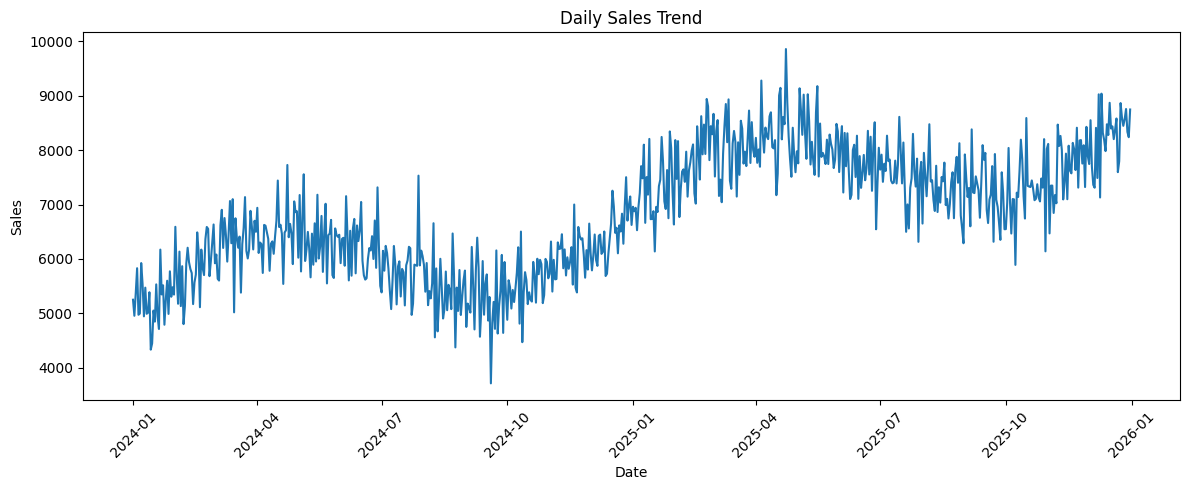

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Sales"])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

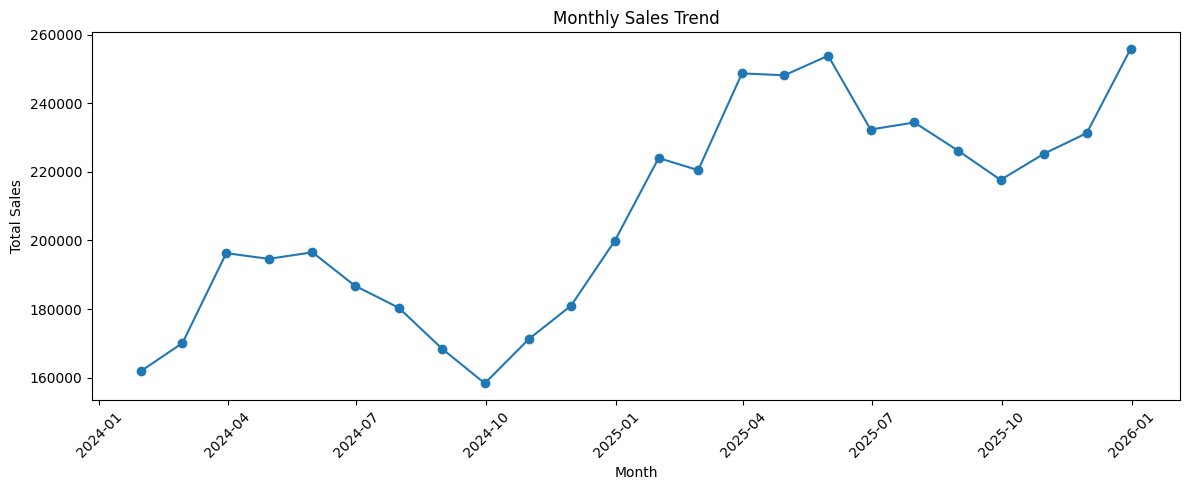

In [8]:
monthly_sales = df.resample("ME", on="Date")["Sales"].sum()

plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

print("Highest Sales Month:", highest_month.strftime("%B %Y"))
print("Highest Sales:", round(highest_sales, 2))

print("Lowest Sales Month:", lowest_month.strftime("%B %Y"))
print("Lowest Sales:", round(lowest_sales, 2))

Highest Sales Month: December 2025
Highest Sales: 255829.2
Lowest Sales Month: September 2024
Lowest Sales: 158329.51


In [10]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df.head()

,Date,Sales,Product,Category,Year,Month,Day
0,2024-01-01,5248.357077,Mobile,Accessories,2024,1,1
1,2024-01-02,4953.081206,Mobile,Accessories,2024,1,2
2,2024-01-03,5368.265881,Laptop,Accessories,2024,1,3
3,2024-01-04,5828.134595,Laptop,Accessories,2024,1,4
4,2024-01-05,4971.725739,Laptop,Accessories,2024,1,5


In [11]:
X = df[["Year", "Month", "Day"]]
y = df["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Year  Month  Day
0  2024      1    1
1  2024      1    2
2  2024      1    3
3  2024      1    4
4  2024      1    5

Target:
0    5248.357077
1    4953.081206
2    5368.265881
3    5828.134595
4    4971.725739
Name: Sales, dtype: float64


In [12]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 584
Testing data: 147


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")


Model training completed!


In [14]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[7800.04838101 7806.35740682 7812.66643263 7818.97545844 7825.28448425
 7831.59351006 7837.90253587 7844.21156168 7850.52058749 7856.8296133 ]


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Square Error (RMSE):", round(rmse, 2))


Mean Absolute Error (MAE): 601.1
Root Mean Square Error (RMSE): 717.02


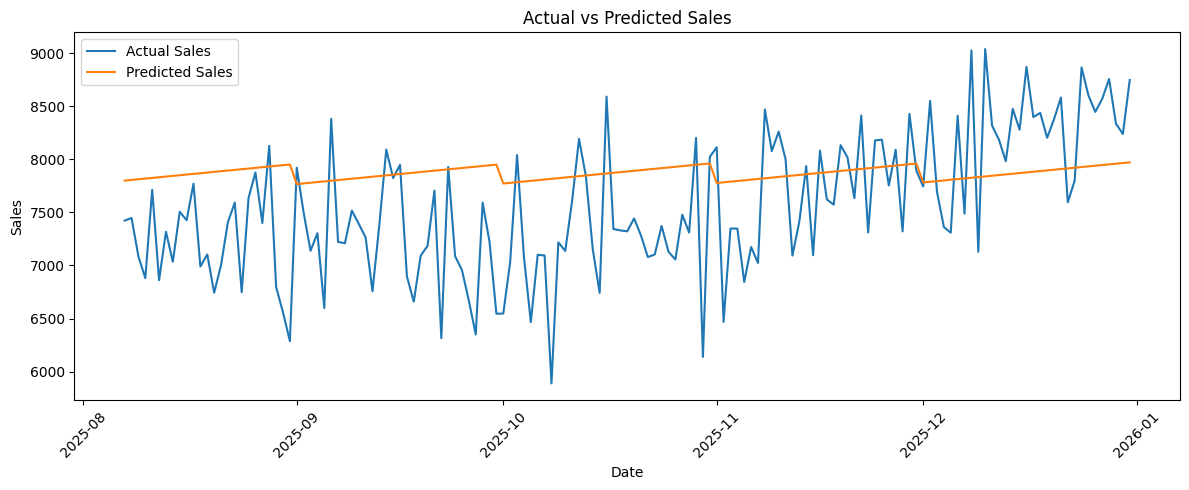

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"].iloc[split_index:],
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    df["Date"].iloc[split_index:],
    y_pred,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
future_dates = pd.date_range(
    start="2026-01-01",
    periods=30,
    freq="D"
)

future_X = pd.DataFrame({
    "Year": future_dates.year,
    "Month": future_dates.month,
    "Day": future_dates.day
})

future_predictions = model.predict(future_X)

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Sales": future_predictions
})

future_forecast.head(10)

,Date,Predicted_Sales
0,2026-01-01,9657.304889
1,2026-01-02,9663.613914
2,2026-01-03,9669.922940
3,2026-01-04,9676.231966
4,2026-01-05,9682.540992
5,2026-01-06,9688.850018
6,2026-01-07,9695.159043
7,2026-01-08,9701.468069
8,2026-01-09,9707.777095
9,2026-01-10,9714.086121


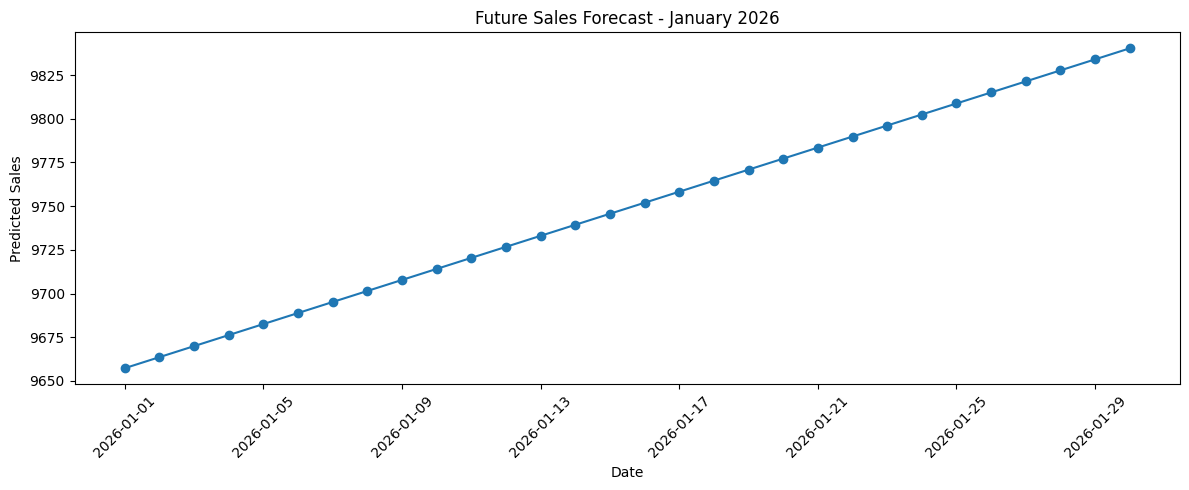

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_Sales"],
    marker="o"
)

plt.title("Future Sales Forecast - January 2026")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    future_sales['Date'],
    future_sales['Predicted_Sales'],
    marker='o'
)

plt.title('Future Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

NameError: name 'future_sales' is not defined

<Figure size 1000x500 with 0 Axes>

In [20]:
# Create future dates for the next 30 days
future_dates = pd.date_range(
    start=df['Date'].max() + pd.Timedelta(days=1),
    periods=30
)

# Create future day numbers
future_days = np.arange(len(df), len(df) + 30)

# Predict future sales
future_predictions = model.predict(future_days.reshape(-1, 1))

# Create future sales table
future_sales = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Sales': future_predictions
})

future_sales

c:\Users\Zoya Ar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


ValueError: X has 1 features, but LinearRegression is expecting 3 features as input.

In [21]:
# Get the last date from the dataset
last_date = df["Date"].max()

# Create dates for the next 30 days
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30
)

# Create future feature values
future_X = X.iloc[-1:].copy()

# Repeat the last feature row for 30 future days
future_X = pd.concat([future_X] * 30, ignore_index=True)

# Predict future sales
future_predictions = model.predict(future_X)

# Create forecast table
future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Sales": future_predictions
})

future_forecast

,Date,Predicted_Sales
0,2026-01-01,7971.861684
1,2026-01-02,7971.861684
2,2026-01-03,7971.861684
3,2026-01-04,7971.861684
4,2026-01-05,7971.861684
5,2026-01-06,7971.861684
6,2026-01-07,7971.861684
7,2026-01-08,7971.861684
8,2026-01-09,7971.861684
9,2026-01-10,7971.861684


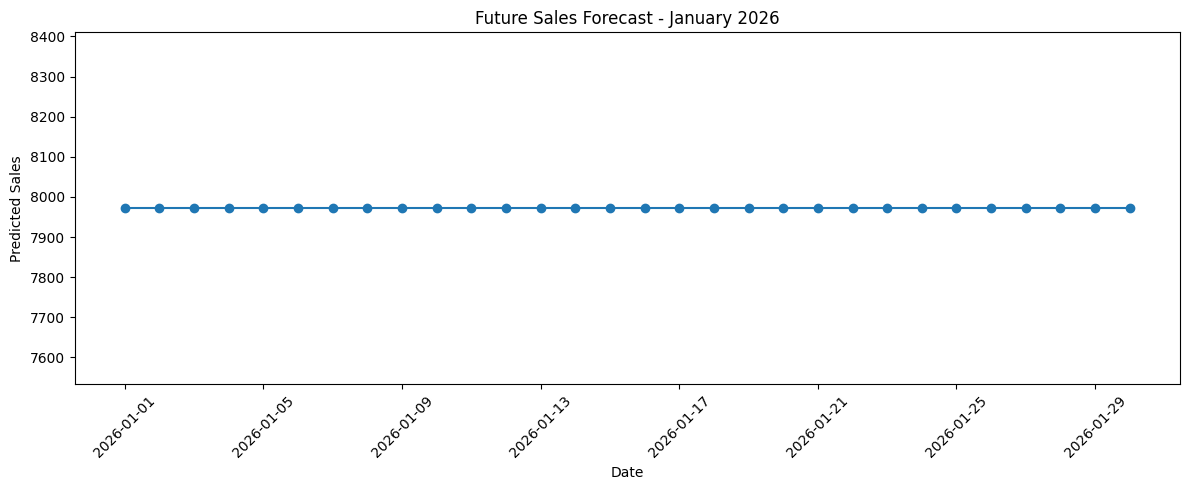

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_Sales"],
    marker="o"
)

plt.title("Future Sales Forecast - January 2026")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
X.columns

Index(['Year', 'Month', 'Day'], dtype='str')

In [24]:
# Create future dates
future_dates = pd.date_range(
    start=df["Date"].max() + pd.Timedelta(days=1),
    periods=30
)

# Create Year, Month and Day features for future dates
future_X = pd.DataFrame({
    "Year": future_dates.year,
    "Month": future_dates.month,
    "Day": future_dates.day
})

# Predict future sales
future_predictions = model.predict(future_X)

# Create forecast table
future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Sales": future_predictions
})

future_forecast

,Date,Predicted_Sales
0,2026-01-01,9657.304889
1,2026-01-02,9663.613914
2,2026-01-03,9669.922940
3,2026-01-04,9676.231966
4,2026-01-05,9682.540992
5,2026-01-06,9688.850018
6,2026-01-07,9695.159043
7,2026-01-08,9701.468069
8,2026-01-09,9707.777095
9,2026-01-10,9714.086121


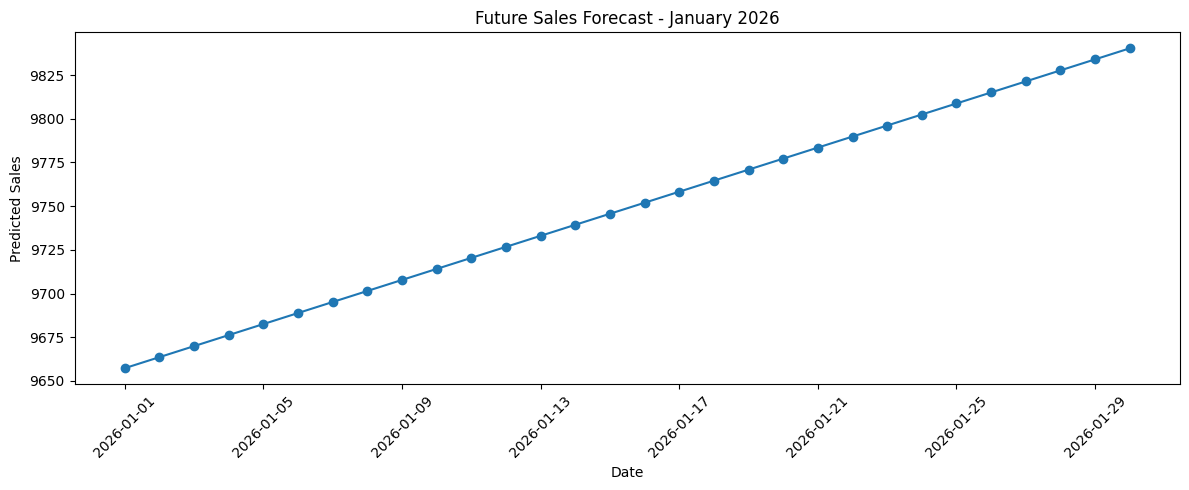

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_Sales"],
    marker="o"
)

plt.title("Future Sales Forecast - January 2026")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
print("Sales Forecasting Model Performance")
print("-----------------------------------")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

Sales Forecasting Model Performance
-----------------------------------
MAE: 601.1031785985477
RMSE: 717.0188298224576


In [30]:
print(df.columns)
print(df.shape)

Index(['Date', 'Sales', 'Product', 'Category', 'Year', 'Month', 'Day'], dtype='str')
(731, 7)


In [31]:
print(df.head())

        Date        Sales Product     Category  Year  Month  Day
0 2024-01-01  5248.357077  Mobile  Accessories  2024      1    1
1 2024-01-02  4953.081206  Mobile  Accessories  2024      1    2
2 2024-01-03  5368.265881  Laptop  Accessories  2024      1    3
3 2024-01-04  5828.134595  Laptop  Accessories  2024      1    4
4 2024-01-05  4971.725739  Laptop  Accessories  2024      1    5


In [29]:
print("""
Conclusion:
The Sales Forecasting model was successfully developed using Linear Regression.
The model used Year, Month, and Day as input features to predict sales.
The model achieved an MAE of 601.10 and an RMSE of 717.02.
It was also used to forecast sales for the next 30 days.
The future forecast showed a gradual increasing trend in predicted sales.
""")


Conclusion:
The Sales Forecasting model was successfully developed using Linear Regression.
The model used Year, Month, and Day as input features to predict sales.
The model achieved an MAE of 601.10 and an RMSE of 717.02.
It was also used to forecast sales for the next 30 days.
The future forecast showed a gradual increasing trend in predicted sales.

